## Trying to check the correlations between the factores that have been Picked

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# ── Step 1: Your factor matrix ────────────────────────────────
# Assume df is your cleaned, forward-filled, differenced dataframe
# Columns: Gold, Crude, USDINR, VIX, FII, DII, Bonds, US10Y,
#          TradeDeficit, GDP, CPI, RepoRate, Nifty, SectorIdx, Volume
#          + ICICI_close as target

factor_cols = [
    'Gold', 'Crude', 'USDINR', 'VIX',
    'FII', 'DII', 'IndBonds', 'US10Y',
    'd_TradeDeficit', 'd_GDP', 'd_CPI', 'd_RepoRate',
    'Nifty', 'SectorIdx', 'Volume'
]

X = df[factor_cols].values          # shape: (n_days, 14)
y = df['ICICI_close'].values        # shape: (n_days,)

# ── Step 2: Standardise — mandatory before projection ─────────
# Each factor is on a different scale (Gold in ₹, VIX in %, etc.)
# Without this, Gold swamps everything just because it's large numbers
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # now every column: mean=0, std=1

# ── Step 3: Project ICICI price onto the factor space ─────────
# This fits: Price = β₀ + β₁F₁ + β₂F₂ + ... + β₁₄F₁₄
reg = LinearRegression()
reg.fit(X_scaled, y)

price_projected = reg.predict(X_scaled)  # the linear combination

# ── Step 4: The residual — this is the KEY output ─────────────
residual = y - price_projected

# Residual = what the factors CANNOT explain
# If residual > 0  → price is above what factors justify  → overpriced
# If residual < 0  → price is below what factors justify  → underpriced

# ── Step 5: See how much each factor contributes ──────────────
loadings = pd.Series(reg.coef_, index=factor_cols).sort_values()
print("Factor loadings (standardised):")
print(loadings)
# Positive loading = factor going up → price goes up
# Negative loading = factor going up → price goes down

# ── Step 6: Check how well the factors explain price ──────────
r2 = reg.score(X_scaled, y)
print(f"\nR² = {r2:.3f}")
# R² = 0.7 means 70% of price movement explained by your 14 factors
# Residual holds the remaining 30% — that's your mean-reversion target

# ── Step 7: Plot actual vs projected ──────────────────────────
plt.figure(figsize=(14, 5))
plt.subplot(2, 1, 1)
plt.plot(df.index, y, label='Actual ICICI', alpha=0.8)
plt.plot(df.index, price_projected, label='Factor projection', alpha=0.8)
plt.legend()
plt.title('Actual vs factor-projected price')

plt.subplot(2, 1, 2)
plt.plot(df.index, residual, color='red', alpha=0.7)
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Residual (what OU will model)')
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

In [5]:
import statsmodels
dir(statsmodels)


['__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '__version_info__',
 '__version_tuple__',
 '_version',
 'compat',
 'debug_warnings',
 'monkey_patch_cat_dtype',
 'test',
 'tools']

In [4]:
help(statsmodels)

Help on package statsmodels:

NAME
    statsmodels

PACKAGE CONTENTS
    _version
    api
    base (package)
    compat (package)
    conftest
    datasets (package)
    discrete (package)
    distributions (package)
    duration (package)
    emplike (package)
    formula (package)
    gam (package)
    genmod (package)
    graphics (package)
    imputation (package)
    interface (package)
    iolib (package)
    miscmodels (package)
    multivariate (package)
    nonparametric (package)
    othermod (package)
    regression (package)
    robust (package)
    sandbox (package)
    src (package)
    stats (package)
    tests (package)
    tools (package)
    treatment (package)
    tsa (package)

FUNCTIONS
    test(extra_args=None, exit=False)
        Run the test suite
        
        Parameters
        ----------
        extra_args : list[str]
            List of argument to pass to pytest when running the test suite. The
            default is ['--tb=short', '--disable-pytest-warn

In [6]:



def load (filename,path, **kwargs):
    df = os.path.join(data-dir,filename)
    pd.read_csv(path,**kwargs)
    if 'date' in df.columns:
        df[date_col]=pd.to_datetime(df[date_col ])
        df=df.set_index(date_col).sort_index()
    return df


In [1]:
import pandas as pd
cd = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/ICICI_Bank_Quarterly_Results_FY2010_FY2026 copy.csv")
cd.head()

,Fiscal Year,Quarter,Period,NII (₹ Cr),NII QoQ Change (₹ Cr),NII YoY Change (₹ Cr),Net Profit (₹ Cr),PAT QoQ Change (₹ Cr),PAT YoY Change (₹ Cr),Data Source
0,FY2010,Q1,Apr–Jun 2009,2100,NaN,NaN,878,NaN,NaN,Estimated
1,FY2010,Q2,Jul–Sep 2009,2079,-21.0,NaN,1038,160.0,NaN,Estimated
2,FY2010,Q3,Oct–Dec 2009,2058,-21.0,NaN,1101,63.0,NaN,NII Confirmed; PAT Derived
3,FY2010,Q4,Jan–Mar 2010,2035,-23.0,NaN,1008,-93.0,NaN,Both Confirmed
4,FY2011,Q1,Apr–Jun 2010,2261,226.0,161.0,1026,18.0,148.0,Estimated


In [ ]:
import pandas as pd
A = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/india_trade_data_monthly.csv")
B = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/bank_nifty_daily.csv")

A['date']=pd.to_datetime(A['date'])
B['date']=pd.to_datetime(B['date'])

B_monthly=B.set_index('date')[['close']].resample('ME').last().reset_index()

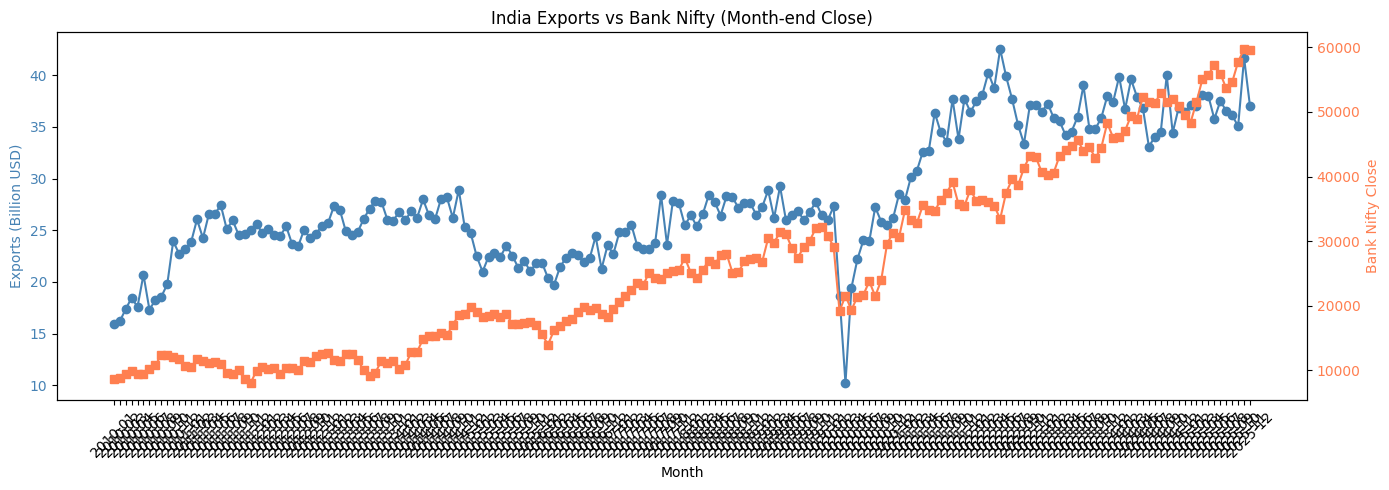

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

A = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/india_trade_data_monthly.csv")
B = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/bank_nifty_daily.csv")

# Parse dates
A["date"] = pd.to_datetime(A["Date"])   # change "date" to your actual date column name
B["date"] = pd.to_datetime(B["Date"])

# Resample Nifty to month-end Close
B_monthly = B.set_index("date")["Close"].resample("ME").last().reset_index()

# Merge on month
A["month"] = A["date"].dt.to_period("M")
B_monthly["month"] = B_monthly["date"].dt.to_period("M")

merged = pd.merge(A[["month", "Exports_Billion_USD"]], B_monthly[["month", "Close"]], on="month")

# Plot
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.set_xlabel("Month")
ax1.set_ylabel("Exports (Billion USD)", color="steelblue")
ax1.plot(merged["month"].astype(str), merged["Exports_Billion_USD"], color="steelblue", marker="o", label="Exports")
ax1.tick_params(axis="y", labelcolor="steelblue")
plt.xticks(rotation=45)

ax2 = ax1.twinx()  # second Y-axis
ax2.set_ylabel("Bank Nifty Close", color="coral")
ax2.plot(merged["month"].astype(str), merged["Close"], color="coral", marker="s", label="Bank Nifty Close")
ax2.tick_params(axis="y", labelcolor="coral")

plt.title("India Exports vs Bank Nifty (Month-end Close)")
fig.tight_layout()
plt.show()

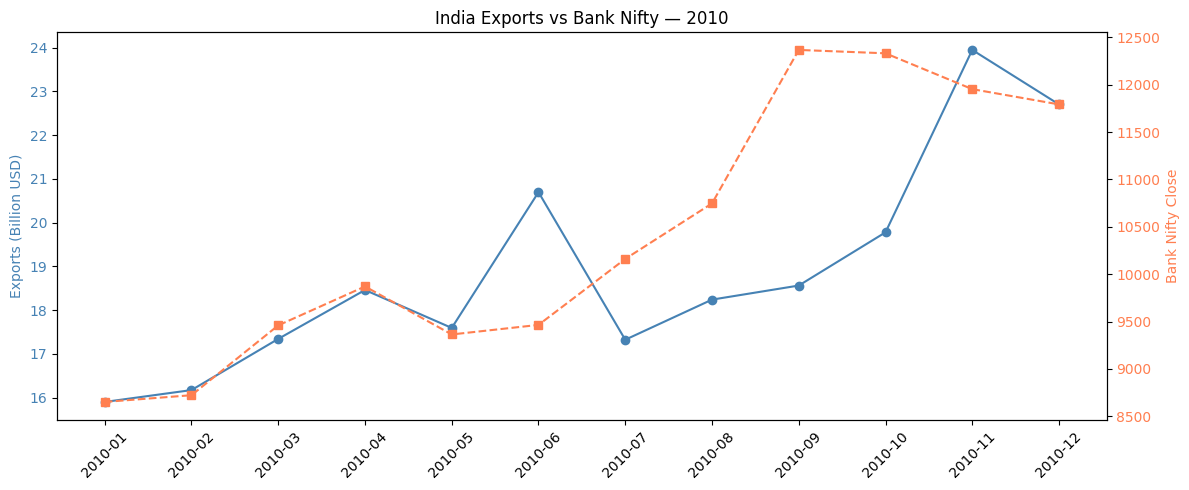

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

A = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/india_trade_data_monthly.csv")
B = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/bank_nifty_daily.csv")

A["Date"] = pd.to_datetime(A["Date"])
B["Date"] = pd.to_datetime(B["Date"])

# Filter 2010
A = A[A["Date"].dt.year == 2010]
B = B[B["Date"].dt.year == 2010]

# Resample Nifty to month-end
B_monthly = B.set_index("Date")["Close"].resample("ME").last().reset_index()

# Merge
A["month"] = A["Date"].dt.to_period("M")
B_monthly["month"] = B_monthly["Date"].dt.to_period("M")
merged = pd.merge(A[["month","Exports_Billion_USD"]], B_monthly[["month","Close"]], on="month")

# Plot
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(merged["month"].astype(str), merged["Exports_Billion_USD"], color="steelblue", marker="o")
ax1.set_ylabel("Exports (Billion USD)", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
plt.xticks(rotation=45)

ax2 = ax1.twinx()
ax2.plot(merged["month"].astype(str), merged["Close"], color="coral", marker="s", linestyle="--")
ax2.set_ylabel("Bank Nifty Close", color="coral")
ax2.tick_params(axis="y", labelcolor="coral")

plt.title("India Exports vs Bank Nifty — 2010")
fig.tight_layout()
plt.show()

In [5]:
print(B[B["Date"].dt.year == 2010].columns.tolist())
print(B[B["Date"].dt.year == 2010].head(12).to_string())

['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'RSI_14']
         Date         Open         High          Low        Close  Volume     RSI_14
0  2010-01-21  9092.894468  9097.994019  8888.946640  8919.196289       0  36.720769
1  2010-01-22  8891.696863  8891.696863  8659.800133  8772.548828       0  29.486735
2  2010-01-25  8724.697913  8751.097995  8669.448558  8696.498047       0  26.564081
3  2010-01-27  8564.500204  8602.550544  8294.503338  8329.703125       0  17.536135
4  2010-01-28  8396.402661  8496.001116  8354.153151  8423.751953       0  24.610981
5  2010-01-29  8346.452765  8686.899002  8306.003040  8651.449219       0  38.391953
6  2010-02-01  8597.350212  8712.148681  8495.151205  8649.149414       0  38.315768
7  2010-02-02  8666.599250  8718.548840  8453.801924  8468.051758       0  32.796724
8  2010-02-03  8489.700874  8662.849247  8489.700874  8631.749023       0  41.060960
9  2010-02-04  8591.699767  8623.149596  8455.401549  8471.000977       0  36.335613
10 2

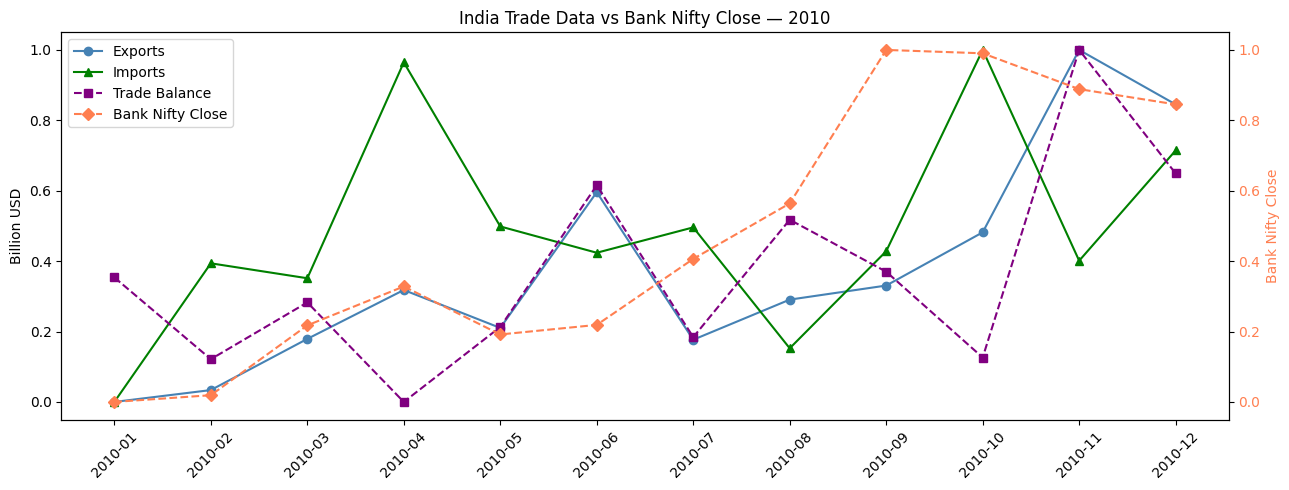

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

A = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/india_trade_data_monthly.csv")
B = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/bank_nifty_daily.csv")

A["Date"] = pd.to_datetime(A["Date"])
B["Date"] = pd.to_datetime(B["Date"])

A = A[A["Date"].dt.year == 2010]
B = B[B["Date"].dt.year == 2010]

B_monthly = B.set_index("Date")["Close"].resample("ME").last().reset_index()

A["month"] = A["Date"].dt.to_period("M")
B_monthly["month"] = B_monthly["Date"].dt.to_period("M")
merged = pd.merge(A[["month","Exports_Billion_USD","Imports_Billion_USD","Trade_Balance_Billion_USD"]], B_monthly[["month","Close"]], on="month")


from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
cols = ["Exports_Billion_USD", "Imports_Billion_USD", "Trade_Balance_Billion_USD", "Close"]
merged[cols] = scaler.fit_transform(merged[cols])


fig, ax1 = plt.subplots(figsize=(13, 5))

months = merged["month"].astype(str)
ax1.plot(months, merged["Exports_Billion_USD"], color="steelblue", marker="o", label="Exports")
ax1.plot(months, merged["Imports_Billion_USD"], color="green", marker="^", label="Imports")
ax1.plot(months, merged["Trade_Balance_Billion_USD"], color="purple", marker="s", linestyle="--", label="Trade Balance")
ax1.set_ylabel("Billion USD")
ax1.tick_params(axis="y")
plt.xticks(rotation=45)

ax2 = ax1.twinx()
ax2.plot(months, merged["Close"], color="coral", marker="D", linestyle="--", label="Bank Nifty Close")
ax2.set_ylabel("Bank Nifty Close", color="coral")
ax2.tick_params(axis="y", labelcolor="coral")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")



plt.title("India Trade Data vs Bank Nifty Close — 2010")
fig.tight_layout()
plt.show()

## Trying to see how many empty volume columns are present

In [29]:
import pandas as pd

nifty = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/nifty50_daily.csv")
bank_nifty=pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/bank_nifty_daily.csv")



print((nifty['Volume']==0).sum())
print((bank_nifty['Volume']==0).sum())
print((icici_bank['Volume']==0).sum())

763
1903
6


In [31]:
print(nifty['Volume'].count(),
bank_nifty['Volume'].count(),
icici_bank['Volume'].count())

4016 4032 4039


In [37]:
nifty[nifty['Volume'] == 0]


,Date,Open,High,Low,Close,Volume,RSI_14
0,2010-01-21,5220.200195,5220.350098,5085.450195,5094.149902,0,25.148825
1,2010-01-22,5094.149902,5094.149902,4954.850098,5036.000000,0,20.746683
2,2010-01-25,5034.549805,5035.700195,4983.049805,5007.899902,0,19.014569
3,2010-01-27,5008.500000,5008.500000,4833.049805,4853.100098,0,12.716159
4,2010-01-28,4863.000000,4929.899902,4824.950195,4867.250000,0,15.472360
...,...,...,...,...,...,...,...
3481,2024-04-01,22455.000000,22529.949219,22427.750000,22462.000000,0,60.933619
3541,2024-07-01,23992.949219,24164.000000,23992.699219,24141.949219,0,70.034813
3542,2024-07-02,24228.750000,24236.349609,24056.400391,24123.849609,0,69.410601
3543,2024-07-03,24291.750000,24309.150391,24207.099609,24286.500000,0,71.839600


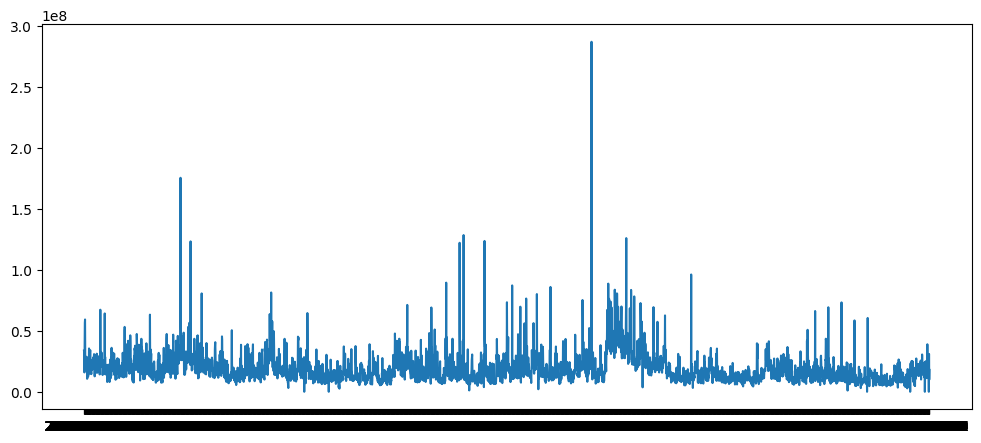

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5 ))
plt.plot(icici_bank['Date'],icici_bank['Volume'],label='Nifty')

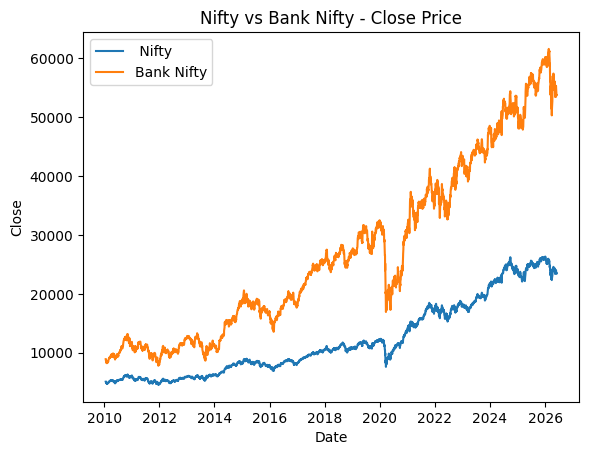

In [36]:
nifty['Date']=pd.to_datetime(nifty['Date'])
bank_nifty['Date']=pd.to_datetime(bank_nifty['Date'])   


plt.plot(nifty['Date'],nifty['Close'],label=' Nifty')
plt.plot(bank_nifty['Date'],bank_nifty['Close'],label='Bank Nifty')

plt.legend()
plt.title('Nifty vs Bank Nifty - Close Price')
plt.xlabel('Date')
plt.ylabel('Close')
plt.show()



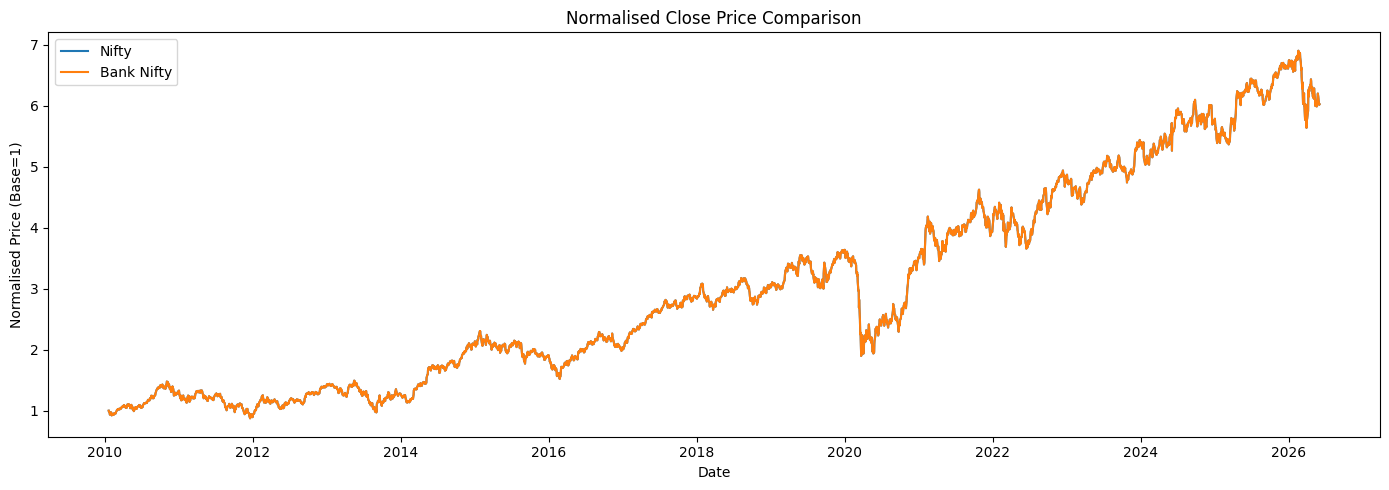

In [28]:
nifty['Close_norm'] = nifty['Close'] / nifty['Close'].iloc[0]
bank_nifty['Close_norm'] = bank_nifty['Close'] / bank_nifty['Close'].iloc[0]


plt.figure(figsize=(14, 5))
plt.plot(nifty['Date'], nifty['Close_norm'], label='Nifty')
plt.plot(bank_nifty['Date'], bank_nifty['Close_norm'], label='Bank Nifty')

plt.legend()
plt.title('Normalised Close Price Comparison')
plt.xlabel('Date')
plt.ylabel('Normalised Price (Base=1)')
plt.tight_layout()
plt.show()


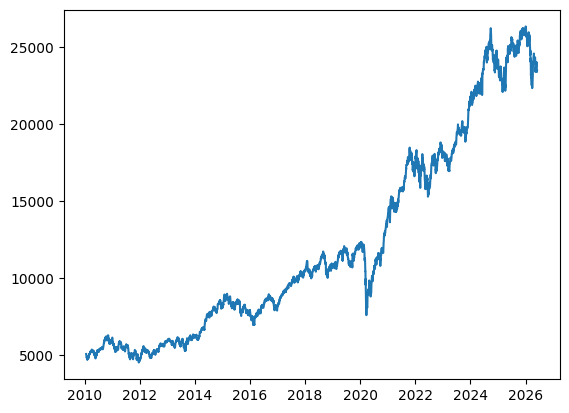

In [39]:

plt.plot(nifty['Date'],nifty['Close'],label='Nifty')

In [40]:
import os 

Direct_path = "/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/"
return_path="/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Model data/"

filename = "nifty50_daily.csv"

def load(Direct_path,filename,**kwargs):
    file=pd.read_csv(os.path.join(Direct_path,filename))
    if "Date" in file.columns:
        file["Date"]=pd.to_datetime(file["Date"])
        file = file.set_index("Date").sort_index()
    return file


nifty=load(Direct_path,filename)

In [19]:
import pandas as pd
tot = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/updatedfiidii.csv")
bankNifty=pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/bank_nifty_daily.csv")


bankNifty_fil = bankNifty[bankNifty["Date"]<= "2022-12-08"]
tot["Sum of Inv"]=tot["FII_Net"]+tot["DII_Net"]


tot["Date"]=pd.to_datetime(tot["Date"])
bankNifty_fil["Date"]=pd.to_datetime(bankNifty_fil["Date"])

tot["Sum of Inv"].head()




/var/folders/10/4p6gdwfx3g74kjfj2_xqxz140000gn/T/ipykernel_14479/327481352.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bankNifty_fil["Date"]=pd.to_datetime(bankNifty_fil["Date"])


0   -294.83
1    558.73
2   -315.87
3   -167.31
4    528.37
Name: Sum of Inv, dtype: float64

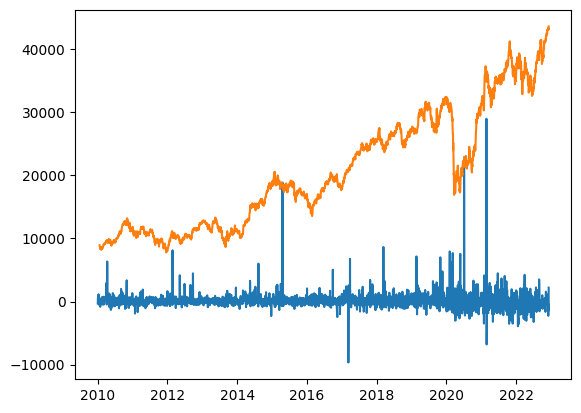

In [20]:
import matplotlib.pyplot as plt
import pandas as pd


plt.plot(tot["Date"],tot["Sum of Inv"])
plt.plot(bankNifty_fil["Date"],bankNifty_fil["Close"])

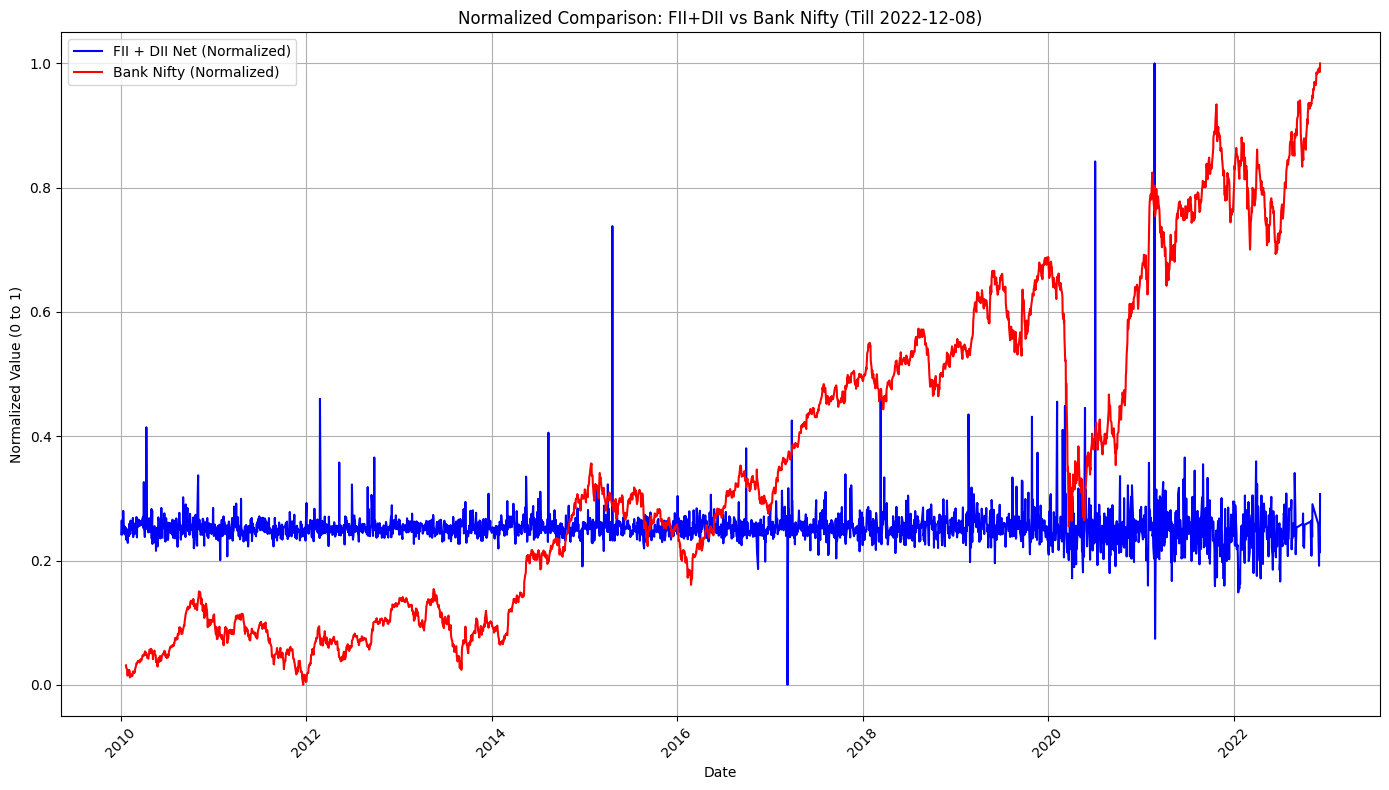

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert dates
tot["Date"] = pd.to_datetime(tot["Date"])
bankNifty["Date"] = pd.to_datetime(bankNifty["Date"])

# Filter Bank Nifty till 2022-12-08
bankNifty_filtered = bankNifty[bankNifty["Date"] <= "2022-12-08"].copy()

# ====================== Normalization ======================
# Min-Max Normalization (0 to 1 scale)

tot["Sum_Inv_Norm"] = (tot["Sum of Inv"] - tot["Sum of Inv"].min()) / (tot["Sum of Inv"].max() - tot["Sum of Inv"].min())

bankNifty_filtered["BankNifty_Norm"] = (bankNifty_filtered["Close"] - bankNifty_filtered["Close"].min()) / \
                                       (bankNifty_filtered["Close"].max() - bankNifty_filtered["Close"].min())

# ====================== Plot ======================
plt.figure(figsize=(14, 8))

plt.plot(tot["Date"], tot["Sum_Inv_Norm"], color='blue', label="FII + DII Net (Normalized)")
plt.plot(bankNifty_filtered["Date"], bankNifty_filtered["BankNifty_Norm"], color='red', label="Bank Nifty (Normalized)")

plt.title("Normalized Comparison: FII+DII vs Bank Nifty (Till 2022-12-08)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (0 to 1)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

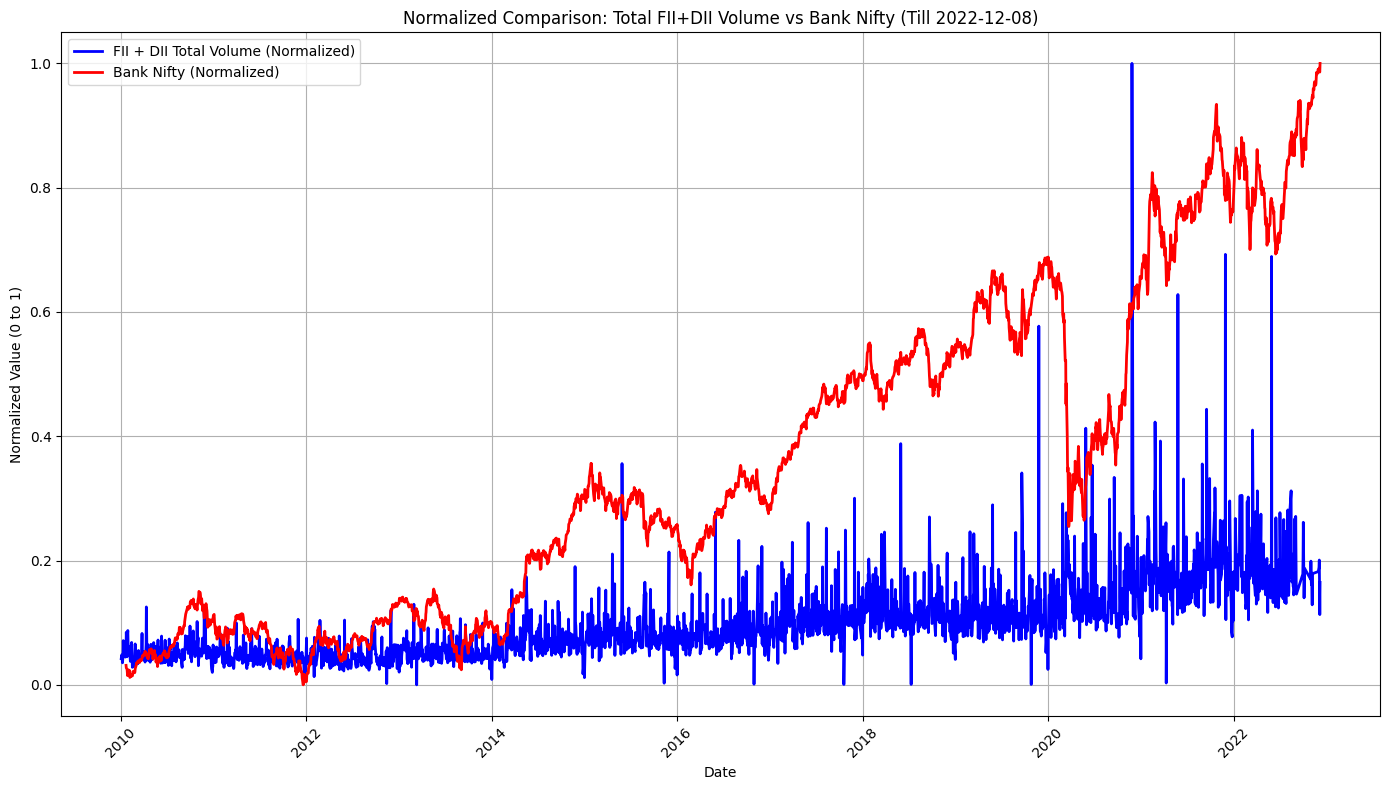

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
tot = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/updatedfiidii.csv")

# Convert Date
tot["Date"] = pd.to_datetime(tot["Date"])

# ============================
# 1. Calculate Total Transaction Volume
# ============================

tot["FII_Volume"] = tot["FII_Buy"] + tot["FII_Sell"]
tot["DII_Volume"] = tot["DII_Buy"] + tot["DII_Sell"]
tot["Total_Volume"] = tot["FII_Volume"] + tot["DII_Volume"]

# ============================
# 2. Load & Filter Bank Nifty
# ============================

bankNifty = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/bank_nifty_daily.csv")        # Change path if needed
bankNifty["Date"] = pd.to_datetime(bankNifty["Date"])
bankNifty_filtered = bankNifty[bankNifty["Date"] <= "2022-12-08"].copy()

# ============================
# 3. Normalization (0 to 1)
# ============================

tot["Total_Volume_Norm"] = (tot["Total_Volume"] - tot["Total_Volume"].min()) / \
                           (tot["Total_Volume"].max() - tot["Total_Volume"].min())

bankNifty_filtered["BankNifty_Norm"] = (bankNifty_filtered["Close"] - bankNifty_filtered["Close"].min()) / \
                                       (bankNifty_filtered["Close"].max() - bankNifty_filtered["Close"].min())

# ============================
# 4. Plot Normalized Comparison
# ============================

plt.figure(figsize=(14, 8))

plt.plot(tot["Date"], tot["Total_Volume_Norm"], 
         color='blue', linewidth=2, label="FII + DII Total Volume (Normalized)")

plt.plot(bankNifty_filtered["Date"], bankNifty_filtered["BankNifty_Norm"], 
         color='red', linewidth=2, label="Bank Nifty (Normalized)")

plt.title("Normalized Comparison: Total FII+DII Volume vs Bank Nifty (Till 2022-12-08)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (0 to 1)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

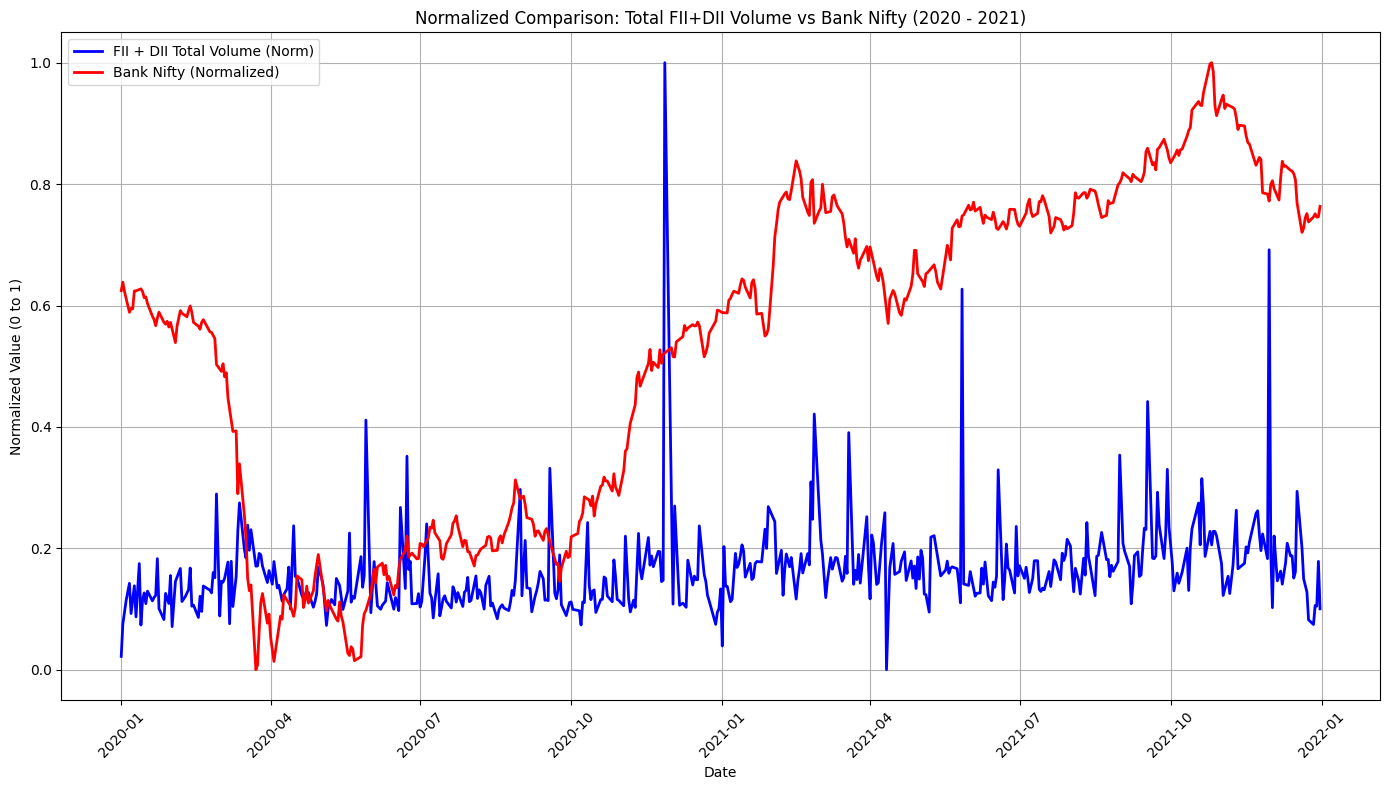

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the new file
tot = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/updatedfiidii.csv")

# Convert Date
tot["Date"] = pd.to_datetime(tot["Date"])

# Filter data from 2020 to 2021
tot_filtered = tot[(tot["Date"] >= "2020-01-01") & (tot["Date"] <= "2021-12-31")].copy()

# ============================
# Calculate Total Volume
# ============================
tot_filtered["FII_Volume"] = tot_filtered["FII_Buy"] + tot_filtered["FII_Sell"]
tot_filtered["DII_Volume"] = tot_filtered["DII_Buy"] + tot_filtered["DII_Sell"]
tot_filtered["Total_Volume"] = tot_filtered["FII_Volume"] + tot_filtered["DII_Volume"]

# ============================
# Load Bank Nifty (Change path if needed)
# ============================
bankNifty = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/bank_nifty_daily.csv")   # ← Update this path
bankNifty["Date"] = pd.to_datetime(bankNifty["Date"])

# Filter Bank Nifty for same period
bankNifty_filtered = bankNifty[(bankNifty["Date"] >= "2020-01-01") & 
                               (bankNifty["Date"] <= "2021-12-31")].copy()

# ============================
# Normalization
# ============================
tot_filtered["Total_Volume_Norm"] = (tot_filtered["Total_Volume"] - tot_filtered["Total_Volume"].min()) / \
                                    (tot_filtered["Total_Volume"].max() - tot_filtered["Total_Volume"].min())

bankNifty_filtered["BankNifty_Norm"] = (bankNifty_filtered["Close"] - bankNifty_filtered["Close"].min()) / \
                                       (bankNifty_filtered["Close"].max() - bankNifty_filtered["Close"].min())

# ============================
# Plot
# ============================
plt.figure(figsize=(14, 8))

plt.plot(tot_filtered["Date"], tot_filtered["Total_Volume_Norm"], 
         color='blue', linewidth=2, label="FII + DII Total Volume (Norm)")

plt.plot(bankNifty_filtered["Date"], bankNifty_filtered["BankNifty_Norm"], 
         color='red', linewidth=2, label="Bank Nifty (Normalized)")

plt.title("Normalized Comparison: Total FII+DII Volume vs Bank Nifty (2020 - 2021)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (0 to 1)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

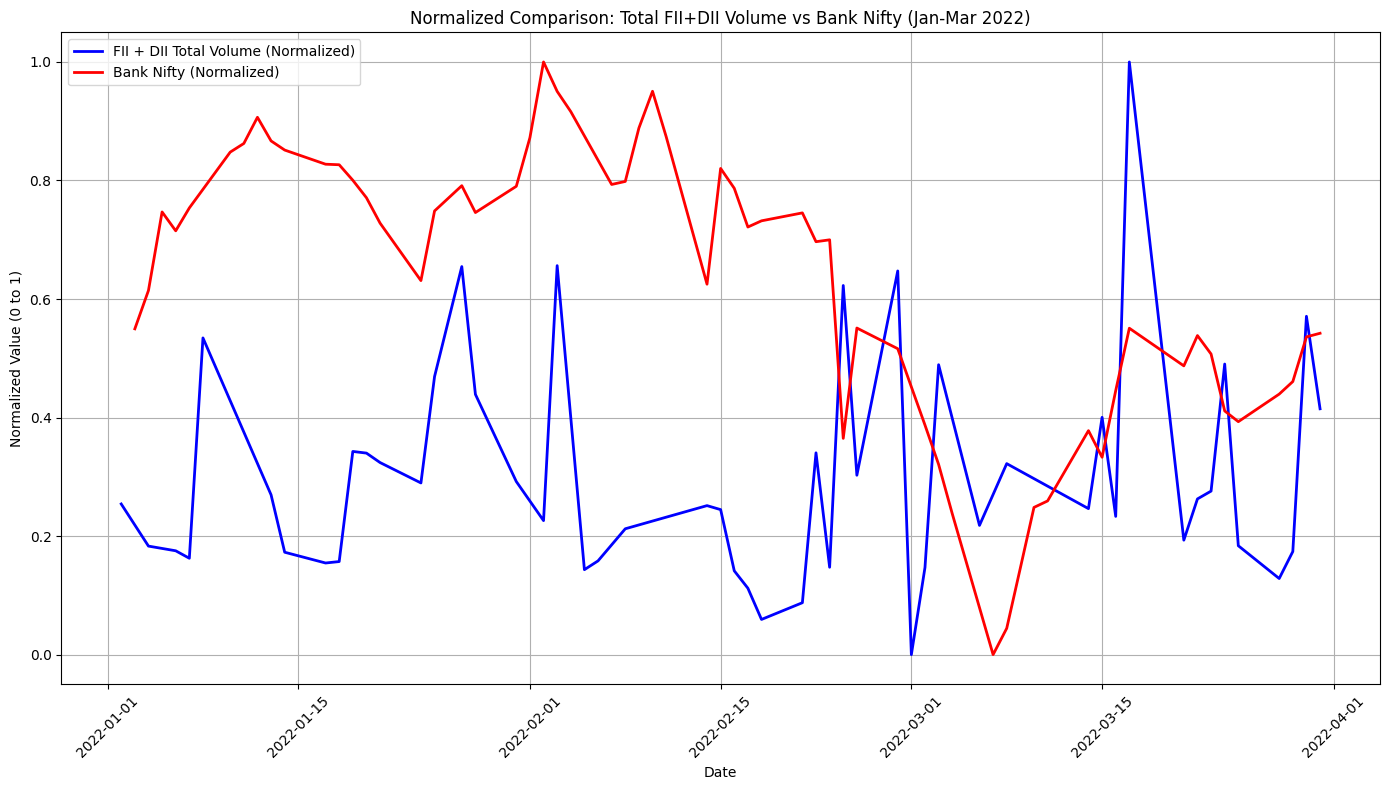

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Load both files
tot = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/updatedfiidii.csv")
bankNifty = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/bank_nifty_daily.csv")

# Convert Date
tot["Date"] = pd.to_datetime(tot["Date"])
bankNifty["Date"] = pd.to_datetime(bankNifty["Date"])

# Filter for 3 months in 2022 (Jan - Mar)
start_date = "2022-01-01"
end_date = "2022-03-31"

tot_filtered = tot[(tot["Date"] >= start_date) & (tot["Date"] <= end_date)].copy()
bankNifty_filtered = bankNifty[(bankNifty["Date"] >= start_date) & 
                               (bankNifty["Date"] <= end_date)].copy()

# Calculate Total Volume
tot_filtered["FII_Volume"] = tot_filtered["FII_Buy"] + tot_filtered["FII_Sell"]
tot_filtered["DII_Volume"] = tot_filtered["DII_Buy"] + tot_filtered["DII_Sell"]
tot_filtered["Total_Volume"] = tot_filtered["FII_Volume"] + tot_filtered["DII_Volume"]

# Normalization
tot_filtered["Total_Volume_Norm"] = (tot_filtered["Total_Volume"] - tot_filtered["Total_Volume"].min()) / \
                                    (tot_filtered["Total_Volume"].max() - tot_filtered["Total_Volume"].min())

bankNifty_filtered["BankNifty_Norm"] = (bankNifty_filtered["Close"] - bankNifty_filtered["Close"].min()) / \
                                       (bankNifty_filtered["Close"].max() - bankNifty_filtered["Close"].min())

# Plot
plt.figure(figsize=(14, 8))
plt.plot(tot_filtered["Date"], tot_filtered["Total_Volume_Norm"], 
         color='blue', linewidth=2, label="FII + DII Total Volume (Normalized)")

plt.plot(bankNifty_filtered["Date"], bankNifty_filtered["BankNifty_Norm"], 
         color='red', linewidth=2, label="Bank Nifty (Normalized)")

plt.title("Normalized Comparison: Total FII+DII Volume vs Bank Nifty (Jan-Mar 2022)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (0 to 1)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
bankNifty_filtered.head()

,Date,Open,High,Low,Close,Volume,RSI_14,BankNifty_Norm
2944,2022-01-03,35585.199219,36492.101562,35526.601562,36421.898438,219000,53.883362,0.549700
2945,2022-01-04,36551.250000,36887.800781,36374.398438,36840.148438,190500,57.633522,0.614452
2946,2022-01-05,36943.550781,37862.398438,36756.351562,37695.898438,237400,64.071217,0.746936
2947,2022-01-06,37242.550781,37752.500000,37058.449219,37490.250000,199000,61.646938,0.715099
2948,2022-01-07,37667.050781,38134.851562,37427.800781,37739.601562,183300,63.452644,0.753702


In [28]:
tot_filtered.head()

,Date,FII_Buy,FII_Sell,FII_Net,DII_Buy,DII_Sell,DII_Net,Nifty_Close,Nifty_Change,Nifty_%Chg,FII_Volume,DII_Volume,Total_Volume,Total_Volume_Norm
2931,2022-01-02,7145.99,7167.78,-21.79,7906.24,6308.54,1597.70,NaN,NaN,NaN,14313.77,14214.78,28528.55,0.254203
2932,2022-01-04,8279.77,6369.99,1909.78,5148.47,5332.26,-183.79,NaN,NaN,NaN,14649.76,10480.73,25130.49,0.183111
2933,2022-01-06,6446.02,8376.18,-1930.16,5457.08,4472.97,984.11,NaN,NaN,NaN,14822.20,9930.05,24752.25,0.175198
2934,2022-01-07,4979.59,7304.33,-2324.74,6588.46,5277.75,1310.71,NaN,NaN,NaN,12283.92,11866.21,24150.13,0.162601
2935,2022-01-08,16377.49,14056.88,2320.61,5331.92,6154.15,-822.23,NaN,NaN,NaN,30434.37,11486.07,41920.44,0.534375


Shape after merging: (45, 19)
        Date  Total_Volume         Close
0 2022-01-04      25130.49  36840.148438
1 2022-01-06      24752.25  37490.250000
2 2022-01-07      24150.13  37739.601562
3 2022-01-13      29264.31  38469.949219
4 2022-01-14      24635.71  38370.398438


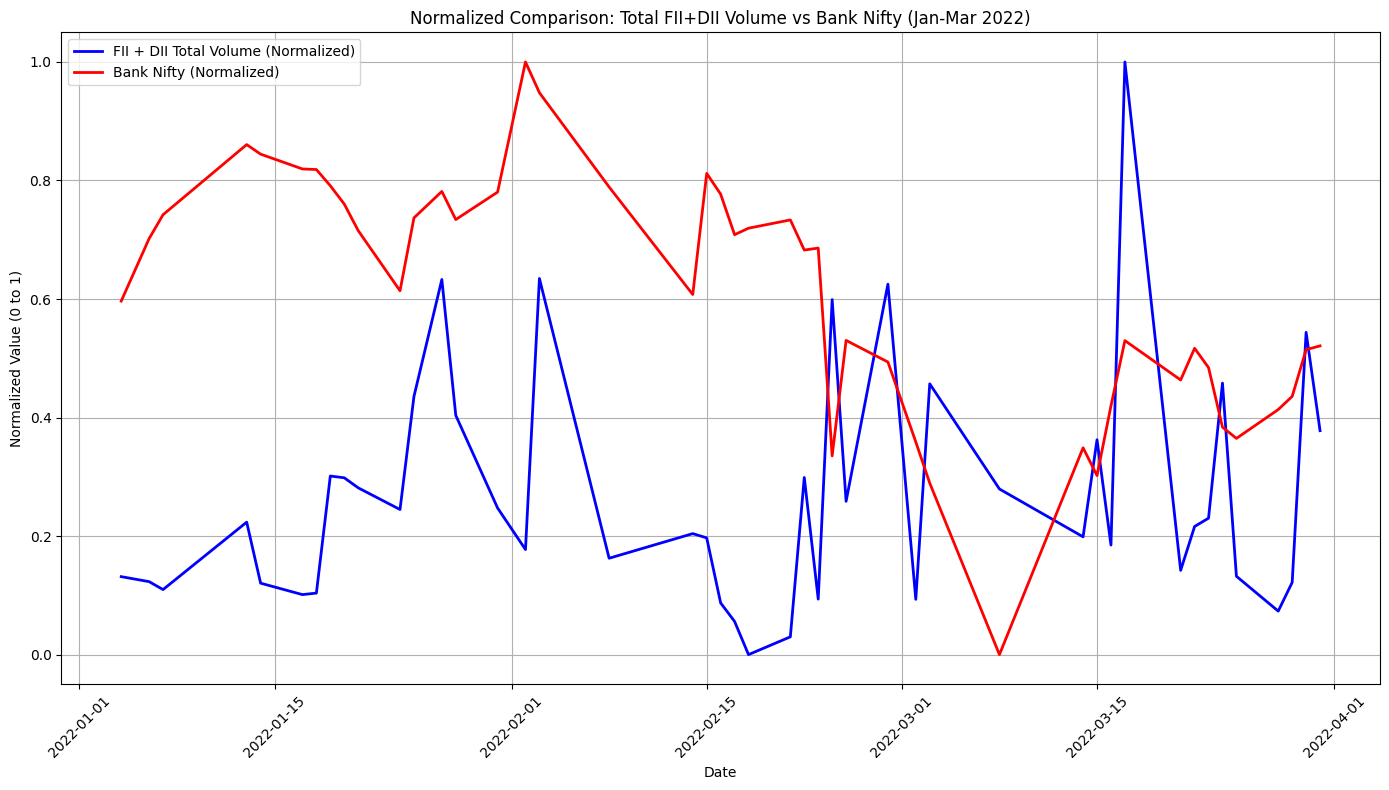

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
tot = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/updatedfiidii.csv")
bankNifty = pd.read_csv("/Users/surisettivamsikrishna/Downloads/Vamsi Pc/Qoin/Cleaned data/bank_nifty_daily.csv")

# Convert to datetime
tot["Date"] = pd.to_datetime(tot["Date"])
bankNifty["Date"] = pd.to_datetime(bankNifty["Date"])

# Filter period
start_date = "2022-01-01"
end_date = "2022-03-31"

tot_filtered = tot[(tot["Date"] >= start_date) & (tot["Date"] <= end_date)].copy()
bankNifty_filtered = bankNifty[(bankNifty["Date"] >= start_date) & 
                               (bankNifty["Date"] <= end_date)].copy()

# ============================
# Calculate Total Volume
# ============================
tot_filtered["FII_Volume"] = tot_filtered["FII_Buy"] + tot_filtered["FII_Sell"]
tot_filtered["DII_Volume"] = tot_filtered["DII_Buy"] + tot_filtered["DII_Sell"]
tot_filtered["Total_Volume"] = tot_filtered["FII_Volume"] + tot_filtered["DII_Volume"]

# ============================
# Merge on Date (Only Common Dates)
# ============================
df = pd.merge(tot_filtered, bankNifty_filtered, on="Date", how="inner")

print("Shape after merging:", df.shape)
print(df[["Date", "Total_Volume", "Close"]].head())

# ============================
# Normalization
# ============================
df["Total_Volume_Norm"] = (df["Total_Volume"] - df["Total_Volume"].min()) / \
                          (df["Total_Volume"].max() - df["Total_Volume"].min())

df["BankNifty_Norm"] = (df["Close"] - df["Close"].min()) / \
                       (df["Close"].max() - df["Close"].min())

# ============================
# Plot
# ============================
plt.figure(figsize=(14, 8))

plt.plot(df["Date"], df["Total_Volume_Norm"], 
         color='blue', linewidth=2, label="FII + DII Total Volume (Normalized)")

plt.plot(df["Date"], df["BankNifty_Norm"], 
         color='red', linewidth=2, label="Bank Nifty (Normalized)")

plt.title("Normalized Comparison: Total FII+DII Volume vs Bank Nifty (Jan-Mar 2022)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (0 to 1)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()